In [31]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import io


In [32]:
# state set up

CELL_SIZE_CM = 3  # real-world cm per grid cell

height = 240
width = 180

N_COLS = width   # discrete x states, x in [0, width)
N_ROWS = height  # discrete y states, y in [0, height)

ORIENTATIONS = {0: "N", 1: "E", 2: "S", 3: "W"}
ORIENTATION_TO_IDX = {name: idx for idx, name in ORIENTATIONS.items()}
N_ORIENTATIONS = len(ORIENTATIONS)


def in_bounds(x, y):
    return 0 <= x < N_COLS and 0 <= y < N_ROWS


def get_position(state):
    """Convert a flat state index into (x, y, orientation).
    Origin (0, 0) is the top-left corner; y increases downward.
    State indices run row-major over (x, y), with orientation as the
    fastest-varying component: state = (y * N_COLS + x) * N_ORIENTATIONS + orientation_idx
    """
    total_states = N_COLS * N_ROWS * N_ORIENTATIONS
    if not (0 <= state < total_states):
        raise ValueError(f"state {state} is out of bounds for a {N_COLS}x{N_ROWS}x{N_ORIENTATIONS} state space")
    o_idx = state % N_ORIENTATIONS
    grid_idx = state // N_ORIENTATIONS
    x = grid_idx % N_COLS
    y = grid_idx // N_COLS
    return x, y, ORIENTATIONS[o_idx]


def get_state(x, y, orientation):
    """orientation: 'N'/'E'/'S'/'W' or its index 0-3."""
    o_idx = orientation if isinstance(orientation, int) else ORIENTATION_TO_IDX[orientation]
    return (y * N_COLS + x) * N_ORIENTATIONS + o_idx


In [33]:
# heading-relative action space, shared by every robot (preprogrammed or learned)
ACTIONS = {0: "stay", 1: "forward", 2: "turn_left", 3: "turn_right"}

# forward displacement by current orientation index (N, E, S, W)
FORWARD_DELTA = {0: (0, -1), 1: (1, 0), 2: (0, 1), 3: (-1, 0)}

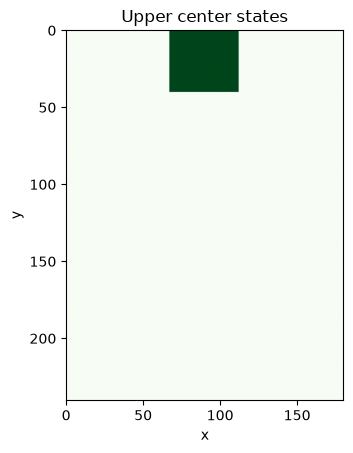

In [34]:
def states_in_region(x_range, y_range, orientations=None):
    """Return all flat state indices whose (x, y) position falls in the given ranges
    and whose orientation is in `orientations` (default: any orientation).
    """
    allowed = set(ORIENTATIONS.values()) if orientations is None else {
        o if isinstance(o, str) else ORIENTATIONS[o] for o in orientations
    }

    total_states = N_COLS * N_ROWS * N_ORIENTATIONS
    states = []
    for state in range(total_states):
        x, y, o = get_position(state)
        if x_range[0] <= x < x_range[1] and y_range[0] <= y < y_range[1] and o in allowed:
            states.append(state)
    return states


# upper center: top 1/6 of the arena (in y), middle 1/4 of the width (in x), any orientation
upper_band = N_ROWS // 6
center_width = N_COLS // 4
x_start = (N_COLS - center_width) // 2
x_end = x_start + center_width

upper_center_states = states_in_region(x_range=(x_start, x_end), y_range=(0, upper_band))


def desired_orientation_idx(dx, dy):
    """Pick the cardinal heading that best reduces the larger remaining offset."""
    if abs(dx) >= abs(dy) and dx != 0:
        return 1 if dx > 0 else 3  # E : W
    elif dy != 0:
        return 2 if dy > 0 else 0  # S : N
    return None  # already at goal


def design_stationary_policy(goal_states):
    """Deterministic tabular policy: state -> action, that turns the agent to
    face the nearest goal cell, then drives forward. We assume the goal region
    is stationary, so the policy depends only on the agent's own state.
    """
    goal_xy = {get_position(s)[:2] for s in goal_states}
    total_states = N_COLS * N_ROWS * N_ORIENTATIONS
    policy = {}

    for state in range(total_states):
        x, y, orientation = get_position(state)
        o_idx = ORIENTATION_TO_IDX[orientation]

        if (x, y) in goal_xy:
            policy[state] = 0  # stay, already in goal region
            continue

        gx, gy = min(goal_xy, key=lambda g: abs(g[0] - x) + abs(g[1] - y))
        target_idx = desired_orientation_idx(gx - x, gy - y)

        if target_idx == o_idx:
            action = 1  # forward
        else:
            diff = (target_idx - o_idx) % 4
            action = 3 if diff in (1, 2) else 2  # turn_right (incl. 180 tie-break) : turn_left

        policy[state] = action

    return policy


def plot_states(states, title="Highlighted states"):
    """Visualize a set of flat states on the N_COLS x N_ROWS arena grid."""
    grid = np.zeros((N_ROWS, N_COLS))
    for x, y in {get_position(s)[:2] for s in states}:
        grid[y, x] = 1

    fig, ax = plt.subplots()
    ax.imshow(grid, origin="upper", cmap="Greens", extent=(0, N_COLS, N_ROWS, 0))
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    plt.show()


plot_states(upper_center_states, title="Upper center states")

In [35]:

def reward(state, goal_states, step_cost=-1, goal_reward=10):
    """Reward for being in `state`. Depends only on reaching the goal region:
    a fixed cost per timestep, plus a bonus once inside the goal region.
    """
    x, y, _ = get_position(state)
    goal_xy = {get_position(s)[:2] for s in goal_states}
    return goal_reward if (x, y) in goal_xy else step_cost

In [36]:
test_policy= design_stationary_policy(upper_center_states)

In [37]:
def transition(state, action):
    """RL transition function T(state, action) -> next_state, heading-aware."""
    x, y, orientation = get_position(state)
    o_idx = ORIENTATION_TO_IDX[orientation]

    if action == 1:  # forward
        dx, dy = FORWARD_DELTA[o_idx]
        nx, ny = x + dx, y + dy
        if in_bounds(nx, ny):
            x, y = nx, ny
    elif action == 2:  # turn_left
        o_idx = (o_idx - 1) % 4
    elif action == 3:  # turn_right
        o_idx = (o_idx + 1) % 4
    # action == 0 (stay): no change

    return get_state(x, y, o_idx)

In [ ]:
def action_to_motor(action):
    """Convert a heading-relative action (stay, forward, turn_left, turn_right)
    into a motor command for the robot. (left wheel, right wheel, duration)
    """
    if action == 0:  # stay
        return (0,0, 1) # third variable is for the duration of the stay
    elif action == 1:  # forward
        return (30, 30, 0.5) # forward half a second 
    elif action == 2:  # turn_left
        return (0, 44, 1)
    elif action == 3:  # turn_right
        return (44, 0, 1)
    else:
        raise ValueError(f"Unknown action {action}")


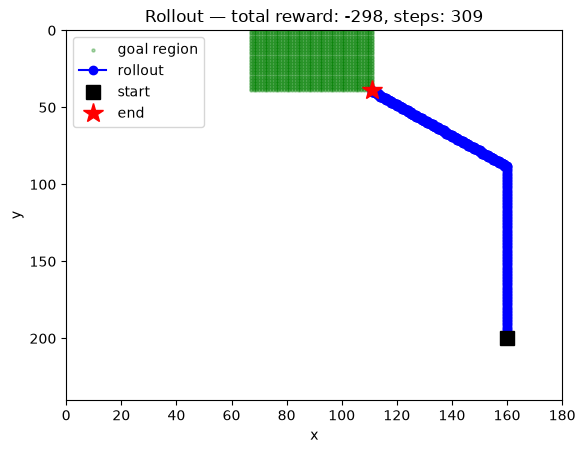

In [41]:
def run_policy(start_state, policy, goal_states, max_steps=500):
    """Roll out `policy` from `start_state` until it reaches the goal region or max_steps."""
    goal_xy = {get_position(s)[:2] for s in goal_states}
    state = start_state
    history = [get_position(state)[:2]]
    rewards = []

    for _ in range(max_steps):
        r = reward(state, goal_states)
        rewards.append(r)
        x, y, _ = get_position(state)
        if (x, y) in goal_xy:
            break
        action = policy[state]
        state = transition(state, action)
        history.append(get_position(state)[:2])

    return history, rewards


start_state = get_state(x=160, y=200, orientation="N")
trajectory, rewards = run_policy(start_state, test_policy, upper_center_states)
xs, ys = zip(*trajectory)

fig, ax = plt.subplots()
for x, y in {get_position(s)[:2] for s in upper_center_states}:
    ax.scatter(x, y, color="green", s=5, alpha=0.3, label="goal region" if (x, y) == next(iter({get_position(s)[:2] for s in upper_center_states})) else None)
ax.plot(xs, ys, "o-", color="blue", label="rollout")
ax.plot(xs[0], ys[0], "s", color="black", markersize=10, label="start")
ax.plot(xs[-1], ys[-1], "*", color="red", markersize=15, label="end")
ax.set_xlim(0, N_COLS)
ax.set_ylim(N_ROWS, 0)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Rollout — total reward: {sum(rewards)}, steps: {len(rewards)}")
ax.legend()
plt.show()


In [12]:
def render_frame(step_idx, vehicles, bounds):
    """Render a single frame: positions of all vehicles up to step_idx."""
    fig, ax = plt.subplots()
    for v in vehicles:
        xs, ys = zip(*v.history[: step_idx + 1])
        ax.plot(xs, ys, "o-", color=v.color, label=v.color)
        ax.plot(xs[-1], ys[-1], "o", color=v.color, markersize=12)  # current position
    ax.set_xlim(bounds[0], bounds[1])
    ax.set_ylim(bounds[2], bounds[3])
    ax.legend()
    ax.set_title(f"step {step_idx}")

    buf = io.BytesIO()
    fig.savefig(buf, format="png")
    plt.close(fig)
    buf.seek(0)
    return imageio.imread(buf)


def make_gif(vehicles, path="./trajectory.gif", duration=0.3, padding=1):
    """Save a gif of all vehicles' trajectories over their recorded history."""
    n_steps = len(vehicles[0].history)

    all_x = [p[0] for v in vehicles for p in v.history]
    all_y = [p[1] for v in vehicles for p in v.history]
    bounds = (min(all_x) - padding, max(all_x) + padding, min(all_y) - padding, max(all_y) + padding)

    with imageio.get_writer(path, mode="I", duration=duration) as writer:
        for step_idx in range(n_steps):
            frame = render_frame(step_idx, vehicles, bounds)
            writer.append_data(frame)

    print(f"GIF written to {path}")


make_gif([green, red, agent])


GIF written to ./trajectory.gif
